# AP M2 — EfficientNetV2-S 4 classes sem data leakage

Notebook completo para o projeto MIQR-CC / CPRE.

Objetivo:
- usar as **4 classes principais** do enunciado;
- evitar **data leakage** com split por `patient_id`;
- manter estratificação aproximada por classe com `StratifiedGroupKFold`;
- treinar um modelo forte com **EfficientNetV2-S**;
- usar **Focal Loss** para lidar com desbalanceamento;
- avaliar com **macro F1**, matriz de confusão, AUC-ROC e PR-AUC;
- gerar **Grad-CAM**;
- guardar resultados para o relatório.

> Nota: este notebook privilegia avaliação correta sem fuga de pacientes entre treino, validação e teste. O macro F1 pode ficar abaixo do split aleatório por imagem, mas é uma avaliação mais rigorosa.

In [1]:
# =========================
# 1. Imports e configuração
# =========================

import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

# Evita alguma fragmentação de memória CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
# =========================
# 2. Configuração principal
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'efficientnetv2s_stratified_group_focal_no_leakage'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
FIGURES_DIR = RESULTS_DIR / 'figures'
CSV_DIR = RESULTS_DIR / 'csv'

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224

# Se der CUDA out of memory, baixa BATCH_SIZE para 4 e aumenta ACCUMULATION_STEPS para 4.
BATCH_SIZE = 8
ACCUMULATION_STEPS = 2

NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 20
PATIENCE = 6

LR_HEAD = 3e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4

FOCAL_GAMMA = 1.5
BASELINE_MACRO_F1 = 0.738

NUM_CLASSES = 4

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/efficientnetv2s_stratified_group_focal_no_leakage
Models: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage


In [3]:
# =========================
# 4. Carregar metadata
# =========================

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

df = pd.read_csv(METADATA_PATH)
print("Shape original:", df.shape)
display(df.head())
print("Colunas:", df.columns.tolist())

required_cols = ["processed_image_path", "patient_id", "Label", "Keep"]
for col in required_cols:
    assert col in df.columns, f"Coluna obrigatória ausente: {col}"

# Manter apenas imagens Keep
df = df[df["Keep"].astype(str).str.lower() == "keep"].copy()

# Remover Unlabelled e labels vazias
df = df[~df["Label"].astype(str).str.lower().isin(["unlabelled", "unlabeled", "nan", "none", ""])].copy()

print("Shape após Keep + remoção Unlabelled:", df.shape)
display(df["Label"].value_counts())

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Shape após Keep + remoção Unlabelled: (1568, 12)


Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64

In [4]:
# =========================
# 5. Mapear para 4 classes principais
# =========================

def map_to_4_classes(label):
    label = str(label).strip()

    if label in ["Benign Stricture", "Malignant Stricture", "Stricture"]:
        return "Stricture"
    elif label in ["Biliary Leaks", "Biliary_Leaks", "Bile Leaks"]:
        return "Biliary Leaks"
    elif label in ["Lithiasis", "Stones", "Biliary lithiasis"]:
        return "Lithiasis"
    elif label == "Normal":
        return "Normal"
    else:
        return None

df["label"] = df["Label"].apply(map_to_4_classes)
df = df[df["label"].notna()].copy()

class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label_idx"] = df["label"].map(class_to_idx).astype(int)
df["patient_id"] = df["patient_id"].astype(str)

print("Distribuição final das 4 classes:")
display(df["label"].value_counts())
print("Total:", len(df))
print("Pacientes:", df["patient_id"].nunique())

df[["Label", "label", "label_idx", "patient_id"]].head()

Distribuição final das 4 classes:


label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

Total: 1568
Pacientes: 436


,Label,label,label_idx,patient_id
23,Normal,Normal,3,3
36,Malignant Stricture,Stricture,2,5
50,Normal,Normal,3,6
65,Malignant Stricture,Stricture,2,9
68,Malignant Stricture,Stricture,2,9


In [5]:
# =========================
# 6. Resolver caminhos das imagens processadas
# =========================

def resolve_processed_path(x):
    x = str(x)
    p = Path(x)

    # Caminho absoluto
    if p.exists():
        return p

    # Caminho relativo ao dataset
    p2 = DATASET_DIR / x
    if p2.exists():
        return p2

    # Caminho relativo à pasta processed pelo nome
    p3 = PROCESSED_IMAGES_DIR / p.name
    if p3.exists():
        return p3

    return None

df["image_path"] = df["processed_image_path"].apply(resolve_processed_path)

missing = df["image_path"].isna().sum()
print(f"Imagens não encontradas: {missing} / {len(df)}")

if missing > 0:
    display(df[df["image_path"].isna()].head())

df = df[df["image_path"].notna()].copy()
df["image_path"] = df["image_path"].astype(str)

print("Shape final com imagens existentes:", df.shape)
display(df[["image_path", "label", "patient_id"]].head())

Imagens não encontradas: 0 / 1568
Shape final com imagens existentes: (1568, 15)


,image_path,label,patient_id
23,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3
36,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,5
50,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,6
65,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,9
68,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,9


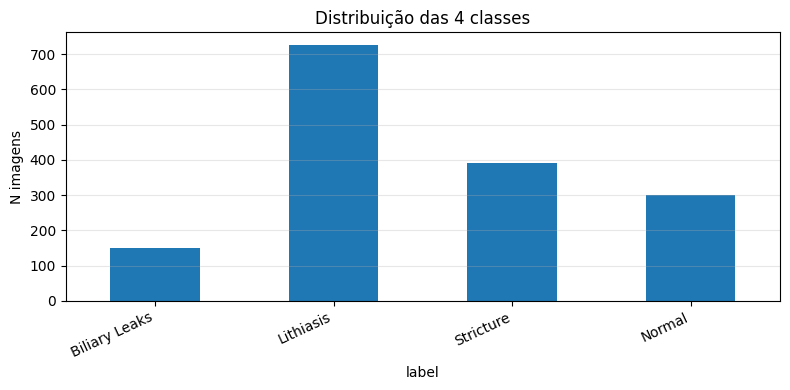

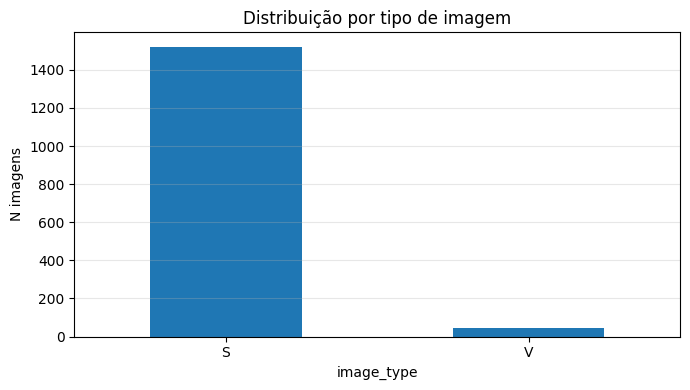

image_type,S,V
label,,
Biliary Leaks,146,5
Lithiasis,712,14
Normal,276,23
Stricture,387,5


In [6]:
# =========================
# 7. EDA — distribuição das classes e image_type
# =========================

plt.figure(figsize=(8, 4))
df["label"].value_counts().reindex(class_names).plot(kind="bar")
plt.title("Distribuição das 4 classes")
plt.ylabel("N imagens")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

if "image_type" in df.columns:
    plt.figure(figsize=(7, 4))
    df["image_type"].value_counts().plot(kind="bar")
    plt.title("Distribuição por tipo de imagem")
    plt.ylabel("N imagens")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_image_type_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    display(pd.crosstab(df["label"], df["image_type"]))

df.to_csv(CSV_DIR / "dataset_4class_filtered.csv", index=False)

In [7]:
# =========================
# 8. Split sem data leakage: StratifiedGroupKFold
# =========================

df = df.reset_index(drop=True).copy()

X = df["image_path"].values
y = df["label_idx"].values
groups = df["patient_id"].values

def distribution_score(train_idx, temp_idx, data):
    classes = sorted(data["label_idx"].unique())

    full_dist = data["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)
    train_dist = data.iloc[train_idx]["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)
    temp_dist = data.iloc[temp_idx]["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)

    # penaliza diferenças face à distribuição global e classes ausentes no temp
    score = np.abs(train_dist - full_dist).sum() + np.abs(temp_dist - full_dist).sum()
    score += 10 * (temp_dist == 0).sum()
    return score

# Primeiro split: treino 80%, temp 20%
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(sgkf.split(X, y, groups))

train_idx, temp_idx = min(
    splits,
    key=lambda split: distribution_score(split[0], split[1], df)
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# Segundo split: temp -> validação/teste, 50/50
X_temp = temp_df["image_path"].values
y_temp = temp_df["label_idx"].values
groups_temp = temp_df["patient_id"].values

sgkf_temp = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
temp_splits = list(sgkf_temp.split(X_temp, y_temp, groups_temp))

val_idx, test_idx = min(
    temp_splits,
    key=lambda split: distribution_score(split[0], split[1], temp_df)
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Split mode: StratifiedGroupKFold sem patient leakage")

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n", name.upper(), "images:", len(split_df), "patients:", split_df["patient_id"].nunique())
    print(split_df["label"].value_counts().reindex(class_names, fill_value=0))

# Verificar leakage
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

leak_train_val = len(train_patients & val_patients)
leak_train_test = len(train_patients & test_patients)
leak_val_test = len(val_patients & test_patients)

print("\nVerificação de leakage por patient_id:")
print("Interseção treino-val:", leak_train_val)
print("Interseção treino-teste:", leak_train_test)
print("Interseção val-teste:", leak_val_test)

assert leak_train_val == 0, "Leakage treino-val"
assert leak_train_test == 0, "Leakage treino-teste"
assert leak_val_test == 0, "Leakage val-teste"

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_images": [len(train_df), len(val_df), len(test_df)],
    "n_patients": [train_df["patient_id"].nunique(), val_df["patient_id"].nunique(), test_df["patient_id"].nunique()]
})
display(split_summary)

train_df.to_csv(CSV_DIR / "train_split.csv", index=False)
val_df.to_csv(CSV_DIR / "val_split.csv", index=False)
test_df.to_csv(CSV_DIR / "test_split.csv", index=False)
split_summary.to_csv(CSV_DIR / "split_summary_no_leakage.csv", index=False)

Split mode: StratifiedGroupKFold sem patient leakage

 TRAIN images: 1266 patients: 346
label
Biliary Leaks    133
Lithiasis        590
Stricture        301
Normal           242
Name: count, dtype: int64

 VAL images: 144 patients: 45
label
Biliary Leaks     2
Lithiasis        73
Stricture        40
Normal           29
Name: count, dtype: int64

 TEST images: 158 patients: 45
label
Biliary Leaks    16
Lithiasis        63
Stricture        51
Normal           28
Name: count, dtype: int64

Verificação de leakage por patient_id:
Interseção treino-val: 0
Interseção treino-teste: 0
Interseção val-teste: 0


,split,n_images,n_patients
0,train,1266,346
1,val,144,45
2,test,158,45


In [8]:
# =========================
# 9. Dataset e transformações
# =========================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

plain_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = int(row["label_idx"])
        return img, label

train_dataset = ERCPDataset(train_df, transform=train_transform)
val_dataset = ERCPDataset(val_df, transform=eval_transform)
test_dataset = ERCPDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 159
Val batches: 18
Test batches: 20


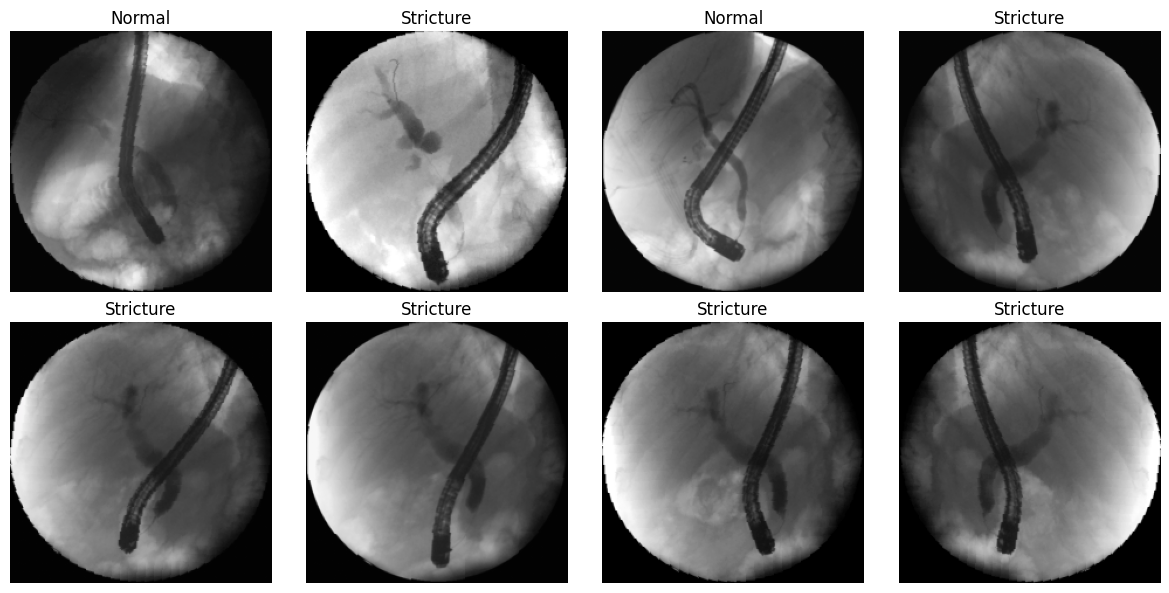

In [9]:
# =========================
# 10. Visualizar amostras
# =========================

def denormalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = t.cpu() * std + mean
    return x.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(min(8, len(train_dataset))):
    img, label = train_dataset[i]
    img_show = denormalize_tensor(img).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show, cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "train_samples.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# =========================
# 11. Focal Loss com pesos suavizados
# =========================

class_counts = train_df["label_idx"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0)
raw_weights = len(train_df) / (NUM_CLASSES * class_counts.replace(0, np.nan))
raw_weights = raw_weights.fillna(0).values.astype(np.float32)

# Suavização para evitar pesos demasiado extremos
smooth_weights = np.sqrt(raw_weights)
smooth_weights = smooth_weights / smooth_weights.mean()

class_weights = torch.tensor(smooth_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts.to_dict())
print("Raw weights:", raw_weights)
print("Smooth weights:", smooth_weights)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)

Class counts: {0: 133, 1: 590, 2: 301, 3: 242}
Raw weights: [2.3796992 0.5364407 1.0514951 1.3078512]
Smooth weights: [1.3884766  0.65923214 0.92295635 1.0293349 ]


In [12]:
# =========================
# 12. Criar modelo EfficientNetV2-S
# =========================

def create_model(num_classes=4):
    weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = models.efficientnet_v2_s(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, num_classes)
    )

    return model

model = create_model(NUM_CLASSES).to(device)
print(model.classifier)

def set_backbone_trainable(model, trainable=False):
    for param in model.features.parameters():
        param.requires_grad = trainable

def set_last_blocks_trainable(model, n_blocks=3):
    for param in model.features.parameters():
        param.requires_grad = False

    for block in model.features[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

# Fase inicial: treinar só a cabeça
set_backbone_trainable(model, trainable=False)
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {trainable:,} / {total:,}")

Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Parâmetros treináveis: 5,124 / 20,182,612


In [13]:
# =========================
# 13. Funções de treino e avaliação
# =========================

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_prob is not None:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(
                y_true_bin, y_prob, average="macro", multi_class="ovr"
            )
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan

        try:
            metrics["pr_auc_macro"] = average_precision_score(
                y_true_bin, y_prob, average="macro"
            )
        except Exception:
            metrics["pr_auc_macro"] = np.nan

    return metrics

def evaluate(model, loader):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)

    metrics = compute_metrics(all_true, all_pred, all_prob)
    metrics["y_true"] = all_true
    metrics["y_pred"] = all_pred
    metrics["y_prob"] = all_prob

    return metrics

def train_one_epoch(model, loader, optimizer, criterion, accumulation_steps=1):
    model.train()

    running_loss = 0.0
    n_samples = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, labels)
            loss_for_backward = loss / accumulation_steps

        scaler.scale(loss_for_backward).backward()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(1, n_samples)

def run_training_phase(model, phase_name, epochs, optimizer, scheduler=None):
    history = []
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_{phase_name}.pt"
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            accumulation_steps=ACCUMULATION_STEPS
        )

        val_metrics = evaluate(model, val_loader)

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_roc_auc_macro_ovr": val_metrics.get("roc_auc_macro_ovr", np.nan),
            "val_pr_auc_macro": val_metrics.get("pr_auc_macro", np.nan),
        }
        history.append(row)

        if scheduler is not None:
            scheduler.step(val_metrics["macro_f1"])

        print(
            f"[{phase_name}] Epoch {epoch:02d}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_auc={val_metrics.get('roc_auc_macro_ovr', np.nan):.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("  -> novo melhor modelo guardado:", best_path)
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping em {phase_name}.")
            break


    return history, best_path, best_val_f1

/tmp/ipykernel_491726/908527125.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [14]:
# =========================
# 14. Fase 1 — treinar cabeça
# =========================

optimizer_head = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler_head = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="max",
    factor=0.5,
    patience=2
)

hist_head, best_head_path, best_head_f1 = run_training_phase(
    model,
    phase_name="head",
    epochs=EPOCHS_HEAD,
    optimizer=optimizer_head,
    scheduler=scheduler_head
)

print("Melhor F1 validação fase head:", best_head_f1)

/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 01/8 | loss=0.7326 | val_macro_f1=0.2378 | val_bal_acc=0.2317 | val_auc=0.5557
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage/best_head.pt


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 02/8 | loss=0.7035 | val_macro_f1=0.1978 | val_bal_acc=0.4061 | val_auc=0.6181


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

[head] Epoch 06/8 | loss=0.6473 | val_macro_f1=0.2463 | val_bal_acc=0.4445 | val_auc=0.6297


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 07/8 | loss=0.6279 | val_macro_f1=0.1781 | val_bal_acc=0.2753 | val_auc=0.5796


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 08/8 | loss=0.6283 | val_macro_f1=0.2496 | val_bal_acc=0.4482 | val_auc=0.6070
Melhor F1 validação fase head: 0.2638852743439601


In [29]:
# =========================
# 15. Fase 2 — fine-tuning parcial
# =========================

# Carregar melhor modelo da fase head
model.load_state_dict(torch.load(best_head_path, map_location=device))

# Descongelar apenas os últimos blocos do backbone
set_last_blocks_trainable(model, n_blocks=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis após fine-tuning parcial: {trainable:,} / {total:,}")

optimizer_ft = torch.optim.AdamW([
    {"params": model.features[-3:].parameters(), "lr": LR_BACKBONE},
    {"params": model.classifier.parameters(), "lr": LR_HEAD * 0.5},
], weight_decay=WEIGHT_DECAY)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=2
)

hist_ft, best_ft_path, best_ft_f1 = run_training_phase(
    model,
    phase_name="finetune",
    epochs=EPOCHS_FINETUNE,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft
)

print("Melhor F1 validação fine-tuning:", best_ft_f1)

Parâmetros treináveis após fine-tuning parcial: 18,361,036 / 20,182,612


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 01/20 | loss=0.6639 | val_macro_f1=0.2662 | val_bal_acc=0.4649 | val_auc=0.6505
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage/best_finetune.pt


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 02/20 | loss=0.6146 | val_macro_f1=0.3065 | val_bal_acc=0.4961 | val_auc=0.6456
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage/best_finetune.pt


...

[finetune] Epoch 18/20 | loss=0.2637 | val_macro_f1=0.5024 | val_bal_acc=0.6058 | val_auc=0.7534
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage/best_finetune.pt


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 19/20 | loss=0.2425 | val_macro_f1=0.4611 | val_bal_acc=0.4923 | val_auc=0.7581


/tmp/ipykernel_491726/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 20/20 | loss=0.2379 | val_macro_f1=0.4812 | val_bal_acc=0.6041 | val_auc=0.7454
Melhor F1 validação fine-tuning: 0.5023672337052618


In [30]:
# =========================
# 16. Escolher melhor modelo global
# =========================

if best_ft_f1 >= best_head_f1:
    best_model_path = best_ft_path
    best_phase = "finetune"
    best_val_f1 = best_ft_f1
else:
    best_model_path = best_head_path
    best_phase = "head"
    best_val_f1 = best_head_f1

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

print("Melhor fase:", best_phase)
print("Melhor Val Macro F1:", best_val_f1)
print("Modelo:", best_model_path)

torch.save(model.state_dict(), MODELS_DIR / "best_model_global.pt")

Melhor fase: finetune
Melhor Val Macro F1: 0.5023672337052618
Modelo: /mounts/mecd-ap-g5/models/efficientnetv2s_stratified_group_focal_no_leakage/best_finetune.pt


,phase,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_roc_auc_macro_ovr,val_pr_auc_macro,global_epoch
23,finetune,16,0.247972,0.437500,0.450537,0.397342,0.441199,0.737336,0.444303,24
24,finetune,17,0.237952,0.458333,0.468833,0.437162,0.460691,0.757677,0.472846,25
25,finetune,18,0.263713,0.500000,0.605760,0.502367,0.499939,0.753438,0.554230,26
26,finetune,19,0.242466,0.479167,0.492324,0.461069,0.481623,0.758139,0.560754,27
27,finetune,20,0.237923,0.486111,0.604107,0.481235,0.487482,0.745386,0.558563,28


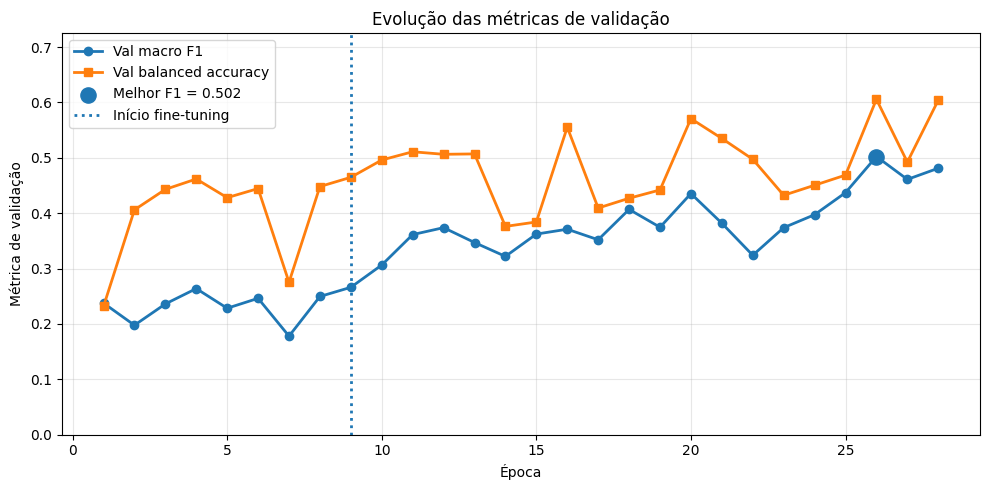

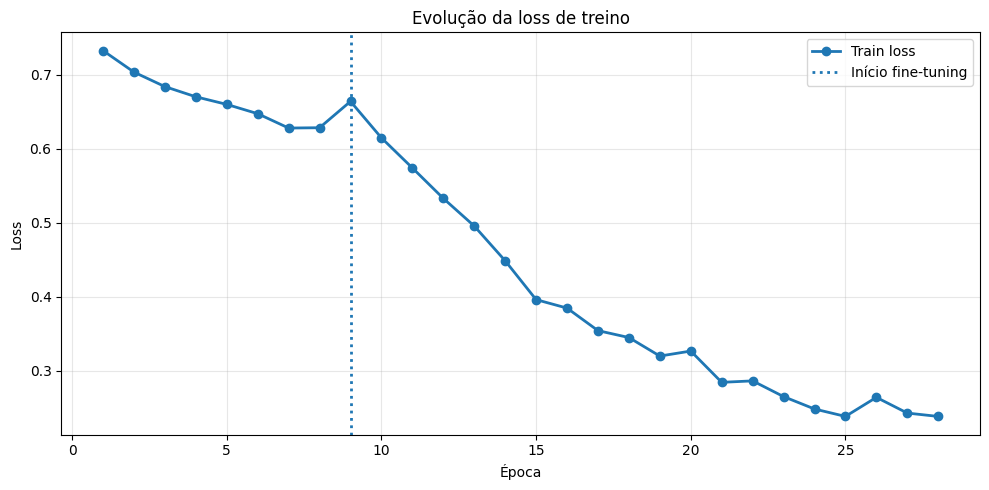

In [31]:
# =========================
# 17. Curvas de treino
# =========================

hist_df = pd.concat([pd.DataFrame(hist_head), pd.DataFrame(hist_ft)], ignore_index=True)
hist_df["global_epoch"] = np.arange(1, len(hist_df) + 1)

hist_df.to_csv(CSV_DIR / "training_history.csv", index=False)
display(hist_df.tail())

phase_change_epoch = None
if hist_df["phase"].nunique() > 1:
    first_phase = hist_df["phase"].iloc[0]
    change_rows = hist_df[hist_df["phase"] != first_phase]
    if len(change_rows) > 0:
        phase_change_epoch = int(change_rows["global_epoch"].iloc[0])

best_idx = hist_df["val_macro_f1"].idxmax()
best_epoch = int(hist_df.loc[best_idx, "global_epoch"])
best_f1 = float(hist_df.loc[best_idx, "val_macro_f1"])

# Gráfico zoomado sem baseline
plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["val_macro_f1"], marker="o", linewidth=2, label="Val macro F1")
plt.plot(hist_df["global_epoch"], hist_df["val_balanced_accuracy"], marker="s", linewidth=2, label="Val balanced accuracy")
plt.scatter(best_epoch, best_f1, s=120, zorder=5, label=f"Melhor F1 = {best_f1:.3f}")

if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")

plt.xlabel("Época")
plt.ylabel("Métrica de validação")
plt.title("Evolução das métricas de validação")
plt.ylim(0, min(1.0, max(hist_df["val_macro_f1"].max(), hist_df["val_balanced_accuracy"].max()) + 0.12))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_metrics_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["train_loss"], marker="o", linewidth=2, label="Train loss")
if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolução da loss de treino")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# =========================
# 18. Avaliação no teste
# =========================

test_metrics = evaluate(model, test_loader)

print("TEST METRICS")
print("Accuracy:", test_metrics["accuracy"])
print("Balanced accuracy:", test_metrics["balanced_accuracy"])
print("Macro F1:", test_metrics["macro_f1"])
print("Weighted F1:", test_metrics["weighted_f1"])
print("ROC-AUC macro OvR:", test_metrics.get("roc_auc_macro_ovr", np.nan))
print("PR-AUC macro:", test_metrics.get("pr_auc_macro", np.nan))

print("\nClassification report:")
report_txt = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    zero_division=0
)
print(report_txt)

report_dict = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_dict).T.to_csv(CSV_DIR / "classification_report_test.csv")

summary = {
    "split_mode": "StratifiedGroupKFold_patient_id_no_leakage",
    "model": "EfficientNetV2-S",
    "loss": "FocalLoss",
    "baseline_macro_f1": BASELINE_MACRO_F1,
    "best_val_macro_f1": float(best_val_f1),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_balanced_accuracy": float(test_metrics["balanced_accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_weighted_f1": float(test_metrics["weighted_f1"]),
    "test_roc_auc_macro_ovr": float(test_metrics.get("roc_auc_macro_ovr", np.nan)),
    "test_pr_auc_macro": float(test_metrics.get("pr_auc_macro", np.nan)),
    "difference_to_baseline": float(test_metrics["macro_f1"] - BASELINE_MACRO_F1),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
    "leak_train_val": int(leak_train_val),
    "leak_train_test": int(leak_train_test),
    "leak_val_test": int(leak_val_test),
}

with open(RESULTS_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

pd.DataFrame([summary]).to_csv(CSV_DIR / "test_summary.csv", index=False)
summary

TEST METRICS
Accuracy: 0.4177215189873418
Balanced accuracy: 0.4519724556489262
Macro F1: 0.41869922002610205
Weighted F1: 0.4185666564959534
ROC-AUC macro OvR: 0.7483117187141692
PR-AUC macro: 0.5047035974516787

Classification report:
               precision    recall  f1-score   support

Biliary Leaks       0.36      0.50      0.42        16
    Lithiasis       0.44      0.30      0.36        63
    Stricture       0.56      0.47      0.51        51
       Normal       0.30      0.54      0.38        28

     accuracy                           0.42       158
    macro avg       0.42      0.45      0.42       158
 weighted avg       0.45      0.42      0.42       158



{'split_mode': 'StratifiedGroupKFold_patient_id_no_leakage',
 'model': 'EfficientNetV2-S',
 'loss': 'FocalLoss',
 'baseline_macro_f1': 0.738,
 'best_val_macro_f1': 0.5023672337052618,
 'test_accuracy': 0.4177215189873418,
 'test_balanced_accuracy': 0.4519724556489262,
 'test_macro_f1': 0.41869922002610205,
 'test_weighted_f1': 0.4185666564959534,
 'test_roc_auc_macro_ovr': 0.7483117187141692,
 'test_pr_auc_macro': 0.5047035974516787,
 'difference_to_baseline': -0.31930077997389794,
 'train_patients': 346,
 'val_patients': 45,
 'test_patients': 45,
 'leak_train_val': 0,
 'leak_train_test': 0,
 'leak_val_test': 0}

In [ ]:
# =========================
# 19. Matriz de confusão
# =========================

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusão — teste")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Matriz normalizada
cm_norm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Matriz de confusão normalizada — teste")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_test_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# 20. Comparação com baseline
# =========================

test_macro_f1 = test_metrics["macro_f1"]
diff = test_macro_f1 - BASELINE_MACRO_F1

print("Baseline macro F1:", BASELINE_MACRO_F1)
print("Macro F1 teste:", test_macro_f1)
print("Diferença:", diff)

plt.figure(figsize=(7, 5))
labels = ["Modelo sem leakage", "Baseline artigo"]
values = [test_macro_f1, BASELINE_MACRO_F1]
bars = plt.bar(labels, values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Macro F1")
plt.title("Comparação com baseline")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "macro_f1_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# 21. Avaliação opcional com TTA no teste
# =========================

def tta_predict_one(model, image_tensor):
    model.eval()

    # image_tensor está normalizado com shape C,H,W
    variants = [
        image_tensor,
        torch.flip(image_tensor, dims=[2]),  # flip horizontal
    ]

    probs_all = []

    with torch.no_grad():
        for img in variants:
            x = img.unsqueeze(0).to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            probs_all.append(probs.cpu())

    probs_mean = torch.mean(torch.stack(probs_all), dim=0)
    return probs_mean.squeeze(0).numpy()

def evaluate_tta(model, dataset):
    y_true = []
    y_prob = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        probs = tta_predict_one(model, img)
        y_true.append(label)
        y_prob.append(probs)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = y_prob.argmax(axis=1)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["y_true"] = y_true
    metrics["y_pred"] = y_pred
    metrics["y_prob"] = y_prob

    return metrics

test_tta_metrics = evaluate_tta(model, test_dataset)

print("TEST METRICS COM TTA")
print("Accuracy:", test_tta_metrics["accuracy"])
print("Balanced accuracy:", test_tta_metrics["balanced_accuracy"])
print("Macro F1:", test_tta_metrics["macro_f1"])
print("Weighted F1:", test_tta_metrics["weighted_f1"])
print("ROC-AUC macro OvR:", test_tta_metrics.get("roc_auc_macro_ovr", np.nan))
print("PR-AUC macro:", test_tta_metrics.get("pr_auc_macro", np.nan))

pd.DataFrame([{
    "test_macro_f1_tta": test_tta_metrics["macro_f1"],
    "test_balanced_accuracy_tta": test_tta_metrics["balanced_accuracy"],
    "test_roc_auc_macro_ovr_tta": test_tta_metrics.get("roc_auc_macro_ovr", np.nan),
    "test_pr_auc_macro_tta": test_tta_metrics.get("pr_auc_macro", np.nan),
}]).to_csv(CSV_DIR / "test_tta_summary.csv", index=False)

In [ ]:
# =========================
# 22. Probabilidades exemplo
# =========================

probs_df = pd.DataFrame(test_metrics["y_prob"], columns=[f"prob_{c}" for c in class_names])
probs_df["true_idx"] = test_metrics["y_true"]
probs_df["pred_idx"] = test_metrics["y_pred"]
probs_df["true_label"] = [idx_to_class[i] for i in test_metrics["y_true"]]
probs_df["pred_label"] = [idx_to_class[i] for i in test_metrics["y_pred"]]
probs_df["image_path"] = test_df.reset_index(drop=True)["image_path"].values

probs_df.to_csv(CSV_DIR / "test_probabilities.csv", index=False)
display(probs_df.head())

In [ ]:
# =========================
# 23. Análise por image_type, se existir
# =========================

if "image_type" in test_df.columns:
    type_df = test_df.reset_index(drop=True).copy()
    type_df["y_true"] = test_metrics["y_true"]
    type_df["y_pred"] = test_metrics["y_pred"]

    rows = []
    for img_type, g in type_df.groupby("image_type"):
        rows.append({
            "image_type": img_type,
            "n": len(g),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "balanced_accuracy": balanced_accuracy_score(g["y_true"], g["y_pred"]),
            "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro", zero_division=0),
        })

    type_metrics_df = pd.DataFrame(rows)
    display(type_metrics_df)
    type_metrics_df.to_csv(CSV_DIR / "metrics_by_image_type.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.bar(type_metrics_df["image_type"], type_metrics_df["macro_f1"])
    plt.ylabel("Macro F1")
    plt.title("Macro F1 por tipo de imagem")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "macro_f1_by_image_type.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Coluna image_type não existe no dataset.")

In [ ]:
# =========================
# 24. Grad-CAM para EfficientNetV2-S
# =========================

# Desativar ReLU inplace para evitar problemas com hooks
def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_inplace_relu(child)

replace_inplace_relu(model)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach().clone()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=False)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam = cam[0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

# Camada alvo: último bloco de features
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

print("Grad-CAM preparado com target_layer = model.features[-1]")

In [ ]:
# =========================
# 25. Mostrar exemplos Grad-CAM por classe
# =========================

def load_original_image_for_display(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img) / 255.0

def show_gradcam_examples(model, dataset, dataframe, n_per_class=2):
    model.eval()

    selected_indices = []

    df_reset = dataframe.reset_index(drop=True)

    for class_idx in range(NUM_CLASSES):
        class_indices = df_reset.index[df_reset["label_idx"] == class_idx].tolist()
        selected_indices.extend(class_indices[:n_per_class])

    n = len(selected_indices)
    if n == 0:
        print("Sem exemplos para Grad-CAM.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_i, idx in enumerate(selected_indices):
        img_tensor, true_label = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)

        cam, logits = gradcam(x)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred_label = int(np.argmax(probs))

        original = load_original_image_for_display(df_reset.iloc[idx]["image_path"])

        axes[row_i, 0].imshow(original)
        axes[row_i, 0].set_title(f"Original\nTrue: {class_names[true_label]}")
        axes[row_i, 0].axis("off")

        axes[row_i, 1].imshow(cam, cmap="jet")
        axes[row_i, 1].set_title("Heatmap Grad-CAM")
        axes[row_i, 1].axis("off")

        axes[row_i, 2].imshow(original)
        axes[row_i, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_i, 2].set_title(
            f"Overlay\nPred: {class_names[pred_label]} ({probs[pred_label]:.2f})"
        )
        axes[row_i, 2].axis("off")

    plt.tight_layout()
    out_path = FIGURES_DIR / "gradcam_examples_by_class.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Grad-CAM guardado em:", out_path)

show_gradcam_examples(model, test_dataset, test_df, n_per_class=2)
gradcam.close()
clean_cuda()

In [ ]:
# =========================
# 26. Guardar configuração final
# =========================

config = {
    "DATA_ROOT": str(DATA_ROOT),
    "DATASET_DIR": str(DATASET_DIR),
    "PROCESSED_IMAGES_DIR": str(PROCESSED_IMAGES_DIR),
    "METADATA_PATH": str(METADATA_PATH),
    "NOTEBOOK_NAME": NOTEBOOK_NAME,
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "ACCUMULATION_STEPS": ACCUMULATION_STEPS,
    "NUM_WORKERS": NUM_WORKERS,
    "EPOCHS_HEAD": EPOCHS_HEAD,
    "EPOCHS_FINETUNE": EPOCHS_FINETUNE,
    "PATIENCE": PATIENCE,
    "LR_HEAD": LR_HEAD,
    "LR_BACKBONE": LR_BACKBONE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "FOCAL_GAMMA": FOCAL_GAMMA,
    "BASELINE_MACRO_F1": BASELINE_MACRO_F1,
    "CLASS_NAMES": class_names,
    "SPLIT_MODE": "StratifiedGroupKFold_by_patient_id",
    "NO_LEAKAGE": True,
    "MODEL": "EfficientNetV2-S",
}

with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print("Ficheiros guardados em:")
print("Results:", RESULTS_DIR)
print("Models:", MODELS_DIR)
print("Figures:", FIGURES_DIR)
print("CSV:", CSV_DIR)

## Notas para o relatório

Pontos que este notebook cobre:

- Análise exploratória da distribuição das classes;
- utilização das imagens processadas;
- classificação multi-classe nas 4 classes do enunciado;
- junção de `Benign Stricture` e `Malignant Stricture` em `Stricture`;
- split treino/validação/teste sem sobreposição de `patient_id`;
- pré-processamento com resize e normalização ImageNet;
- augmentation moderada para robustez;
- balanceamento com Focal Loss e pesos suavizados;
- modelo EfficientNetV2-S com transfer learning;
- fine-tuning parcial;
- macro F1, weighted F1, balanced accuracy, AUC-ROC e PR-AUC;
- matriz de confusão;
- probabilidades por classe;
- comparação com baseline 0.738;
- Grad-CAM para interpretabilidade.